# Three Ways to Compute a Derivative

So far you have computed derivatives *by hand*, applying rules like the Chain Rule on paper. A computer actually has **three** different ways to obtain a derivative, and they are not the same thing:

1. **Symbolic differentiation** — apply the same rules you know (chain rule, product rule, ...) mechanically, producing an exact formula.
2. **Numerical differentiation** — approximate the derivative from function *values* only, using the definition of the derivative as a limit.
3. **Automatic differentiation (AD)** — compute the *exact* derivative value at a point without ever building a symbolic formula, by propagating derivatives through every elementary operation. This is exactly the Chain Rule, applied mechanically — and it is the technique that trains every neural network you have heard of (that is what "backpropagation" actually is).

We will compute the derivative of $h(x) = e^{\cos(2x)}$ — the function from **Ejercicio 07A01(c)** — all three ways, and compare them at the same points you already used: $x_0 = \pi/6$ and $x_0 = \pi$.

## 1. Symbolic differentiation

In [1]:
import numpy as np
import sympy as sy

x_sym = sy.Symbol('x')
h_sym = sy.exp(sy.cos(2*x_sym))
dh_sym = sy.diff(h_sym, x_sym)

print(f"h(x)  = {h_sym}")
print(f"h'(x) = {dh_sym}")

h(x)  = exp(cos(2*x))
h'(x) = -2*exp(cos(2*x))*sin(2*x)


sympy just applied the Chain Rule for you, mechanically: $h = e^{g(x)}$ with $g(x) = \cos(2x)$, so $h' = e^{g(x)} \cdot g'(x)$. Let's turn both into numeric functions with `lambdify` and check them at the two points from the exercise.

In [2]:
h_num = sy.lambdify(x_sym, h_sym, 'numpy')
dh_num = sy.lambdify(x_sym, dh_sym, 'numpy')

x0 = np.pi/6
x1 = np.pi   # the point used in Ejercicio 07A01(c)

print("Exact (symbolic) at x0 = pi/6:", sy.simplify(dh_sym.subs(x_sym, sy.pi/6)))
print("Numeric evaluation          :", dh_num(x0))
print()
print("Exact (symbolic) at x1 = pi  :", sy.simplify(dh_sym.subs(x_sym, sy.pi)))
print("Numeric evaluation          :", dh_num(x1))

Exact (symbolic) at x0 = pi/6: -sqrt(3)*exp(1/2)
Numeric evaluation          : -2.8556690083721428

Exact (symbolic) at x1 = pi  : 0
Numeric evaluation          : 1.3315740561611136e-15


## 2. Numerical differentiation

The derivative is *defined* as a limit:
$$h'(x_0) = \lim_{h\to 0} \frac{h(x_0+h) - h(x_0)}{h}$$

A computer cannot take a limit — it can only evaluate $h$ at specific points. The obvious idea is to pick a small $h$ and compute the difference quotient directly (**forward difference**), or a slightly better version that cancels more error (**central difference**):
$$\text{forward: } \frac{h(x_0+h)-h(x_0)}{h} \qquad \text{central: } \frac{h(x_0+h)-h(x_0-h)}{2h}$$

Neither of these needs the Chain Rule, or any derivative rule at all — just function *values*. That is both their strength (they work on data, or on functions you cannot differentiate by hand) and their weakness, as we're about to see.

In [3]:
def forward_diff(f, x, h):
    return (f(x+h) - f(x)) / h

def central_diff(f, x, h):
    return (f(x+h) - f(x-h)) / (2*h)

exact = dh_num(x0)
print(f"exact derivative at x0 = pi/6: {exact}\n")
for h in [1e-1, 1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-12]:
    fd = forward_diff(h_num, x0, h)
    cd = central_diff(h_num, x0, h)
    print(f"h={h:>8.0e}  forward={fd:.10f} (err {abs(fd-exact):.2e})   "
          f"central={cd:.10f} (err {abs(cd-exact):.2e})")

exact derivative at x0 = pi/6: -2.8556690083721428

h=   1e-01  forward=-2.7437167005 (err 1.12e-01)   central=-2.8224143857 (err 3.33e-02)
h=   1e-02  forward=-2.8470960245 (err 8.57e-03)   central=-2.8553358529 (err 3.33e-04)
h=   1e-04  forward=-2.8555865390 (err 8.25e-05)   central=-2.8556689751 (err 3.33e-08)
h=   1e-06  forward=-2.8556681841 (err 8.24e-07)   central=-2.8556690084 (err 3.87e-13)
h=   1e-08  forward=-2.8556690124 (err 4.00e-09)   central=-2.8556690124 (err 4.00e-09)
h=   1e-10  forward=-2.8556712550 (err 2.25e-06)   central=-2.8556701448 (err 1.14e-06)
h=   1e-12  forward=-2.8557156639 (err 4.67e-05)   central=-2.8556046416 (err 6.44e-05)


Look closely: the error goes **down** as $h$ shrinks... until around $h=10^{-8}$, and then it starts going **up** again. This never happens with symbolic differentiation, and it is a genuinely computational phenomenon:

* For large $h$, the approximation itself is bad (**truncation error** — the difference quotient isn't really the tangent slope unless $h$ is small).
* For very small $h$, $h(x_0+h)$ and $h(x_0)$ become nearly-equal floating point numbers, and subtracting them cancels out most of the significant digits (**round-off error**).

The best $h$ is a trade-off between these two effects, not "as small as possible". Let's visualize it.

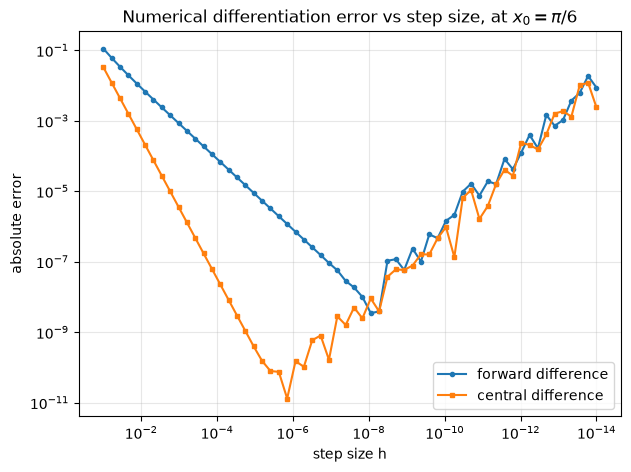

In [4]:
import matplotlib.pyplot as plt

hs = np.logspace(-1, -14, 60)
fwd_err = [abs(forward_diff(h_num, x0, h) - exact) for h in hs]
cen_err = [abs(central_diff(h_num, x0, h) - exact) for h in hs]

plt.figure(figsize=(7, 5))
plt.loglog(hs, fwd_err, 'o-', label='forward difference', markersize=3)
plt.loglog(hs, cen_err, 's-', label='central difference', markersize=3)
plt.xlabel('step size h')
plt.ylabel('absolute error')
plt.title("Numerical differentiation error vs step size, at $x_0=\\pi/6$")
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.gca().invert_xaxis()
plt.show()

The characteristic **V-shape** is the signature of floating-point numerical differentiation. Central difference (slope $\approx 2$ on the log-log plot, i.e. error $\propto h^2$) beats forward difference (slope $\approx 1$, error $\propto h$) on the way down, and also bottoms out lower — but *both* eventually lose to round-off error. This kind of error analysis has no analogue in pencil-and-paper calculus; it only exists because we are computing in finite-precision floating point.

## 3. Automatic differentiation (dual numbers)

There is a third option that gets an **exact** derivative value, without the round-off problems of finite differences and without ever building a symbolic formula.

The trick: extend numbers to **dual numbers** $a + b\varepsilon$, with the rule $\varepsilon^2 = 0$ (and $\varepsilon \ne 0$). If we evaluate a function $f$ at $x = a + 1\cdot\varepsilon$ and Taylor-expand, every term with $\varepsilon^2$ or higher vanishes:
$$f(a + \varepsilon) = f(a) + f'(a)\,\varepsilon + \underbrace{\tfrac{1}{2}f''(a)\varepsilon^2 + \cdots}_{=\,0} = f(a) + f'(a)\,\varepsilon$$

So the $\varepsilon$-coefficient of the result **is** the derivative — automatically, for free, as long as every elementary operation we implement (+, ×, sin, exp, ...) respects this rule. And look closely at how each rule below is written: **each one *is* the Chain Rule**, hard-coded for one elementary function. Composing them via ordinary function calls chains the rule automatically — that's the whole idea.

In [5]:
class Dual:
    def __init__(self, val, eps=0.0):
        self.val = val   # the value  f(a)
        self.eps = eps   # the derivative f'(a), carried alongside

    def __repr__(self):
        return f"Dual({self.val}, {self.eps})"

    def __add__(self, other):
        other = other if isinstance(other, Dual) else Dual(other)
        return Dual(self.val + other.val, self.eps + other.eps)
    __radd__ = __add__

    def __sub__(self, other):
        other = other if isinstance(other, Dual) else Dual(other)
        return Dual(self.val - other.val, self.eps - other.eps)

    def __rsub__(self, other):
        return Dual(other) - self

    def __mul__(self, other):
        other = other if isinstance(other, Dual) else Dual(other)
        # product rule, encoded directly: (uv)' = u'v + uv'
        return Dual(self.val * other.val, self.eps * other.val + self.val * other.eps)
    __rmul__ = __mul__

    def __truediv__(self, other):
        other = other if isinstance(other, Dual) else Dual(other)
        # quotient rule: (u/v)' = (u'v - uv') / v^2
        return Dual(self.val / other.val,
                     (self.eps * other.val - self.val * other.eps) / other.val**2)

    def __pow__(self, n):
        # power rule (n constant): (u^n)' = n u^(n-1) u'
        return Dual(self.val**n, n * self.val**(n-1) * self.eps)

def dsin(u):
    u = u if isinstance(u, Dual) else Dual(u)
    return Dual(np.sin(u.val), np.cos(u.val) * u.eps)    # Chain Rule: cos(u)*u'

def dcos(u):
    u = u if isinstance(u, Dual) else Dual(u)
    return Dual(np.cos(u.val), -np.sin(u.val) * u.eps)   # Chain Rule: -sin(u)*u'

def dexp(u):
    u = u if isinstance(u, Dual) else Dual(u)
    return Dual(np.exp(u.val), np.exp(u.val) * u.eps)    # Chain Rule: exp(u)*u'

In [6]:
def h_dual(x):
    return dexp(dcos(2*x))

for pt, name in [(x0, "pi/6"), (x1, "pi")]:
    d = h_dual(Dual(pt, 1.0))   # seed: derivative of x itself is 1
    print(f"x0 = {name:>4}:  h(x0) = {d.val:.10f}   h'(x0) via AD = {d.eps:.10f}")

x0 = pi/6:  h(x0) = 1.6487212707   h'(x0) via AD = -2.8556690084
x0 =   pi:  h(x0) = 2.7182818285   h'(x0) via AD = 0.0000000000


Notice what did **not** happen: at no point did we build a symbolic expression for $h'(x)$, and at no point did we pick a step size $h$ or worry about round-off. We just evaluated $h$ normally, on a slightly richer number type, and the exact derivative came out attached to the answer.

This is **forward-mode** automatic differentiation. Real deep learning frameworks (PyTorch, JAX, TensorFlow) mostly use **reverse-mode** AD ("backpropagation"), which is more efficient when a function has many inputs and one output — like a neural network's loss function — but the underlying idea is identical: propagate a *(value, derivative)* pair through every elementary operation using exactly the Chain Rule.

## Head-to-head comparison

In [7]:
print(f"{'point':>8} {'symbolic':>16} {'central diff (h=1e-6)':>24} {'autodiff':>16}")
for pt, name in [(x0, "pi/6"), (x1, "pi")]:
    sym_val = dh_num(pt)
    cd_val = central_diff(h_num, pt, 1e-6)
    ad_val = h_dual(Dual(pt, 1.0)).eps
    print(f"{name:>8} {sym_val:>16.10f} {cd_val:>24.10f} {ad_val:>16.10f}")

   point         symbolic    central diff (h=1e-6)         autodiff
    pi/6    -2.8556690084            -2.8556690084    -2.8556690084
      pi     0.0000000000             0.0000000000     0.0000000000


All three methods agree — as they must, since they are all computing the same number. What differs is **how** they get there, and that difference matters in practice:

* **Symbolic** is the right choice when you want an actual formula, or insight into the structure of a problem — but as compositions get deeper, symbolic expressions can explode in size (something worth exploring separately).
* **Numerical** is the only option when you don't have a formula at all — e.g. a function only known from measured data or a black-box simulation — but it is approximate and sensitive to floating-point error.
* **Automatic differentiation** gets the accuracy of symbolic differentiation with the convenience of "just evaluate the function", and it scales to functions with millions of operations. It is the default choice throughout modern scientific computing — and it is, quite literally, the Chain Rule you practiced in Ejercicio 07A01, applied mechanically one elementary operation at a time.